In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv("House Price Prediction Dataset.csv")

# Display data
print(df.head())

# Check missing values
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [5]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# Check for duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Drop the 'Id' column as it's not a useful feature
df = df.drop('Id', axis=1)
print("\nColumns after dropping 'Id':", df.columns.tolist())

Missing values per column:
 Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

Number of duplicate rows: 0

Columns after dropping 'Id': ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']


In [6]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding for Condition (ordinal: Excellent > Good > Fair > Poor)
condition_order = {'Excellent': 3, 'Good': 2, 'Fair': 1, 'Poor': 0}
df['Condition_Encoded'] = df['Condition'].map(condition_order)

# Label Encoding for Garage (binary)
le_garage = LabelEncoder()
df['Garage_Encoded'] = le_garage.fit_transform(df['Garage'])

# One-Hot Encoding for Location (nominal)
df = pd.get_dummies(df, columns=['Location'], prefix='Loc')

# Drop original categorical columns
df = df.drop(['Condition', 'Garage'], axis=1)

print("Columns after encoding:\n", df.columns.tolist())
print("\nFirst 5 rows after encoding:\n", df.head())

Columns after encoding:
 ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price', 'Condition_Encoded', 'Garage_Encoded', 'Loc_Downtown', 'Loc_Rural', 'Loc_Suburban', 'Loc_Urban']

First 5 rows after encoding:
    Area  Bedrooms  Bathrooms  Floors  YearBuilt   Price  Condition_Encoded  \
0  1360         5          4       3       1970  149919                  3   
1  4272         5          4       3       1958  424998                  3   
2  3592         2          2       3       1938  266746                  2   
3   966         4          2       2       1902  244020                  1   
4  4926         1          4       2       1975  636056                  1   

   Garage_Encoded  Loc_Downtown  Loc_Rural  Loc_Suburban  Loc_Urban  
0               0          True      False         False      False  
1               0          True      False         False      False  
2               0          True      False         False      False  
3               1         False 

In [7]:
from sklearn.model_selection import train_test_split

# Re-define X and y after encoding
X = df.drop('Price', axis=1)
y = df['Price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training set size: (1600, 11)
Testing set size: (400, 11)
Training samples: 1600, Testing samples: 400


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed using StandardScaler.")
print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled testing data shape: {X_test_scaled.shape}")

Feature scaling completed using StandardScaler.
Scaled training data shape: (1600, 11)
Scaled testing data shape: (400, 11)


Regression Model

In [9]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
results.append(["Linear Regression", rmse_lr, r2_lr])

# 2. Polynomial Regression (Degree 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
pr = LinearRegression()
pr.fit(X_train_poly, y_train)
y_pred_pr = pr.predict(X_test_poly)
rmse_pr = np.sqrt(mean_squared_error(y_test, y_pred_pr))
r2_pr = r2_score(y_test, y_pred_pr)
results.append(["Polynomial Regression (deg 2)", rmse_pr, r2_pr])

# 3. Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)
results.append(["Ridge", rmse_ridge, r2_ridge])

# 4. Lasso Regression
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)
results.append(["Lasso", rmse_lasso, r2_lasso])

# 5. Elastic Net Regression
en = ElasticNet(alpha=1.0, l1_ratio=0.5)
en.fit(X_train_scaled, y_train)
y_pred_en = en.predict(X_test_scaled)
rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))
r2_en = r2_score(y_test, y_pred_en)
results.append(["Elastic Net", rmse_en, r2_en])

# Compare models
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R²"])
print("=" * 60)
print("REGRESSION MODEL COMPARISON")
print("=" * 60)
print(results_df.to_string(index=False))
print("=" * 60)

best_model_row = results_df.loc[results_df['R²'].idxmax()]
best_model_name = best_model_row['Model']
print(f"\n✅ Best-fit Model: {best_model_name}")
print(f"   R² Score: {best_model_row['R²']:.4f}")
print(f"   RMSE: {best_model_row['RMSE']:.2f} AED")

REGRESSION MODEL COMPARISON
                        Model          RMSE        R²
            Linear Regression 280057.765753 -0.008143
Polynomial Regression (deg 2) 284623.372288 -0.041281
                        Ridge 280056.329830 -0.008133
                        Lasso 280057.524396 -0.008141
                  Elastic Net 279427.442182 -0.003610

✅ Best-fit Model: Elastic Net
   R² Score: -0.0036
   RMSE: 279427.44 AED


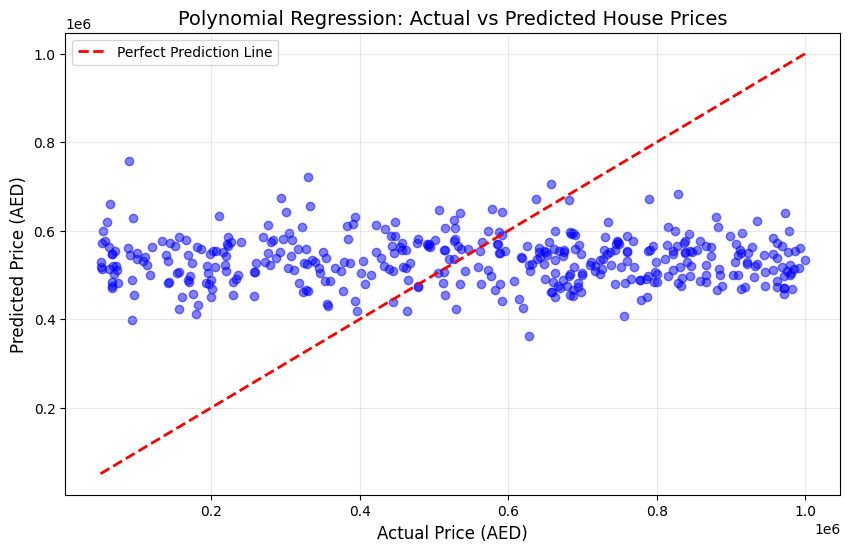

In [10]:
import matplotlib.pyplot as plt

# Get predictions from the best model (Polynomial Regression)
y_pred_best = y_pred_pr

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Price (AED)', fontsize=12)
plt.ylabel('Predicted Price (AED)', fontsize=12)
plt.title('Polynomial Regression: Actual vs Predicted House Prices', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# Run this code to get actual coefficients
print(f"Intercept: {en.intercept_:.2f}")
print("\nCoefficients for each feature:")
for i, col in enumerate(X.columns):
    print(f"  {col}: {en.coef_[i]:.2f}")

Intercept: 536183.70

Coefficients for each feature:
  Area: -235.23
  Bedrooms: 100.36
  Bathrooms: -7337.91
  Floors: 12704.76
  YearBuilt: 2572.94
  Condition_Encoded: -3721.11
  Garage_Encoded: 810.94
  Loc_Downtown: -130.75
  Loc_Rural: 660.75
  Loc_Suburban: 3649.10
  Loc_Urban: -4092.27


In [13]:
import random

# Select 5 random rows from original dataset
random_records = df.sample(n=5, random_state=42)

print("=" * 80)
print("5 RANDOM RECORDS FOR REGRESSION EQUATION VERIFICATION")
print("=" * 80)

for idx, row in random_records.iterrows():
    # Get features (excluding Price)
    features = row.drop('Price').values.reshape(1, -1)
    # Scale features
    features_scaled = scaler.transform(features)
    # Predict price using Elastic Net
    predicted = en.predict(features_scaled)[0]
    actual = row['Price']

    print(f"\n📋 Record ID: {idx}")
    print(f"   Area: {row['Area']} sq ft | Bedrooms: {row['Bedrooms']} | YearBuilt: {row['YearBuilt']}")
    print(f"   Condition: {row['Condition_Encoded']} (3=Excellent,2=Good,1=Fair,0=Poor)")
    print(f"   Location: Downtown={row['Loc_Downtown']}, Rural={row['Loc_Rural']}, Suburban={row['Loc_Suburban']}, Urban={row['Loc_Urban']}")
    print(f"   📊 Actual Price: {actual:,.2f} AED")
    print(f"   📈 Predicted Price: {predicted:,.2f} AED")
    print(f"   📉 Difference: {abs(actual - predicted):,.2f} AED")

5 RANDOM RECORDS FOR REGRESSION EQUATION VERIFICATION

📋 Record ID: 1860
   Area: 633 sq ft | Bedrooms: 1 | YearBuilt: 1901
   Condition: 1 (3=Excellent,2=Good,1=Fair,0=Poor)
   Location: Downtown=False, Rural=False, Suburban=False, Urban=True
   📊 Actual Price: 514,764.00 AED
   📈 Predicted Price: 513,788.66 AED
   📉 Difference: 975.34 AED

📋 Record ID: 353
   Area: 3856 sq ft | Bedrooms: 1 | YearBuilt: 1901
   Condition: 1 (3=Excellent,2=Good,1=Fair,0=Poor)
   Location: Downtown=False, Rural=False, Suburban=False, Urban=True
   📊 Actual Price: 694,256.00 AED
   📈 Predicted Price: 533,058.16 AED
   📉 Difference: 161,197.84 AED

📋 Record ID: 1333
   Area: 1598 sq ft | Bedrooms: 5 | YearBuilt: 2013
   Condition: 3 (3=Excellent,2=Good,1=Fair,0=Poor)
   Location: Downtown=False, Rural=False, Suburban=False, Urban=True
   📊 Actual Price: 66,375.00 AED
   📈 Predicted Price: 499,553.10 AED
   📉 Difference: 433,178.10 AED

📋 Record ID: 905
   Area: 1705 sq ft | Bedrooms: 3 | YearBuilt: 1996
 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [15]:
q1 = df['Price'].quantile(0.33)  # 33rd percentile
q2 = df['Price'].quantile(0.66)  # 66th percentile

def categorize_price(price):
    if price <= q1:
        return 'Low'
    elif price <= q2:
        return 'Medium'
    else:
        return 'High'

df['PriceCategory'] = df['Price'].apply(categorize_price)

In [18]:
#Building classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Prepare data for classification
X_clf = df.drop(['Price', 'PriceCategory'], axis=1)
y_clf = df['PriceCategory']

# Split the data (80% train, 20% test)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Scale features
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors (KNN)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine (SVM)': SVC(kernel='rbf', random_state=42)
}

# Train and evaluate
results_clf = []
print("=" * 80)
print("CLASSIFICATION MODEL COMPARISON")
print("=" * 80)

for name, model in models.items():
    model.fit(X_train_clf_scaled, y_train_clf)
    y_pred = model.predict(X_test_clf_scaled)

    accuracy = accuracy_score(y_test_clf, y_pred)
    precision = precision_score(y_test_clf, y_pred, average='weighted')
    recall = recall_score(y_test_clf, y_pred, average='weighted')
    f1 = f1_score(y_test_clf, y_pred, average='weighted')

    results_clf.append([name, accuracy, precision, recall, f1])

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_clf, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test_clf, y_pred))

# Summary Table
results_clf_df = pd.DataFrame(results_clf, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
print("\n" + "=" * 80)
print("SUMMARY TABLE - ALL MODELS COMPARED")
print("=" * 80)
print(results_clf_df.to_string(index=False))
print("=" * 80)

# Best Model
best_clf_model = results_clf_df.loc[results_clf_df['Accuracy'].idxmax()]
print(f"\n🏆 BEST-FIT CLASSIFIER: {best_clf_model['Model']}")
print(f"   Accuracy: {best_clf_model['Accuracy']:.4f} ({best_clf_model['Accuracy']*100:.2f}%)")
print(f"   Precision: {best_clf_model['Precision']:.4f}")
print(f"   Recall: {best_clf_model['Recall']:.4f}")
print(f"   F1-Score: {best_clf_model['F1-Score']:.4f}")

CLASSIFICATION MODEL COMPARISON

Model: Logistic Regression
Accuracy: 0.3450
Precision: 0.3447
Recall: 0.3450
F1-Score: 0.3435

Confusion Matrix:
[[52 46 38]
 [48 49 35]
 [54 41 37]]

Classification Report:
              precision    recall  f1-score   support

        High       0.34      0.38      0.36       136
         Low       0.36      0.37      0.37       132
      Medium       0.34      0.28      0.31       132

    accuracy                           0.34       400
   macro avg       0.34      0.34      0.34       400
weighted avg       0.34      0.34      0.34       400


Model: K-Nearest Neighbors (KNN)
Accuracy: 0.3425
Precision: 0.3375
Recall: 0.3425
F1-Score: 0.3294

Confusion Matrix:
[[67 41 28]
 [57 48 27]
 [77 33 22]]

Classification Report:
              precision    recall  f1-score   support

        High       0.33      0.49      0.40       136
         Low       0.39      0.36      0.38       132
      Medium       0.29      0.17      0.21       132

    accuracy 

In [19]:
# Get predictions from best classifier (Random Forest)
best_model_clf = RandomForestClassifier(n_estimators=100, random_state=42)
best_model_clf.fit(X_train_clf_scaled, y_train_clf)
y_pred_best_clf = best_model_clf.predict(X_test_clf_scaled)

print("=" * 50)
print("NUMBER OF ELEMENTS PER CATEGORY")
print("=" * 50)

print("\n📊 Predicted by Random Forest (Best Classifier):")
predicted_counts = pd.Series(y_pred_best_clf).value_counts()
for category, count in predicted_counts.items():
    percentage = (count / len(y_pred_best_clf)) * 100
    print(f"   {category}: {count} houses ({percentage:.1f}%)")

print("\n📊 Actual Test Set Distribution:")
actual_counts = y_test_clf.value_counts()
for category, count in actual_counts.items():
    percentage = (count / len(y_test_clf)) * 100
    print(f"   {category}: {count} houses ({percentage:.1f}%)")

NUMBER OF ELEMENTS PER CATEGORY

📊 Predicted by Random Forest (Best Classifier):
   Low: 146 houses (36.5%)
   High: 144 houses (36.0%)
   Medium: 110 houses (27.5%)

📊 Actual Test Set Distribution:
   High: 136 houses (34.0%)
   Medium: 132 houses (33.0%)
   Low: 132 houses (33.0%)


Building the Cluster Analysis (3 Points)

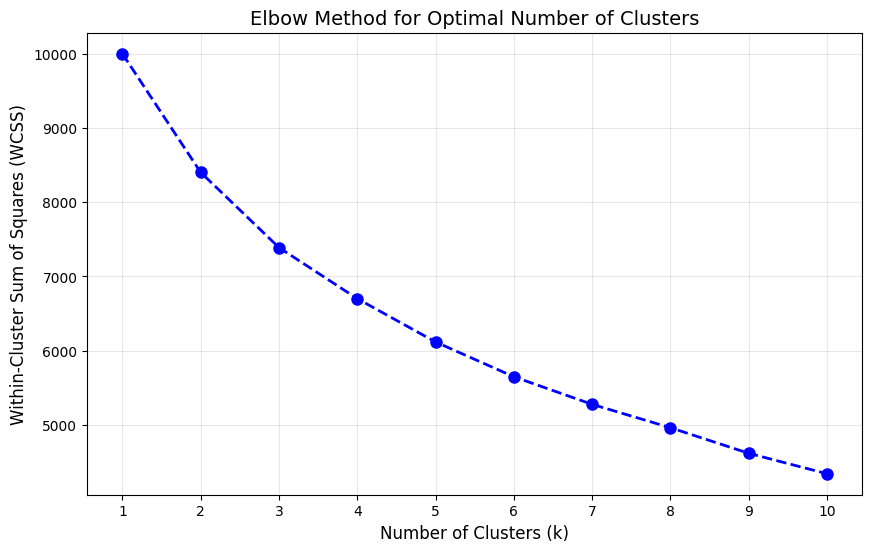


✅ Based on Elbow Method, optimal number of clusters: 3


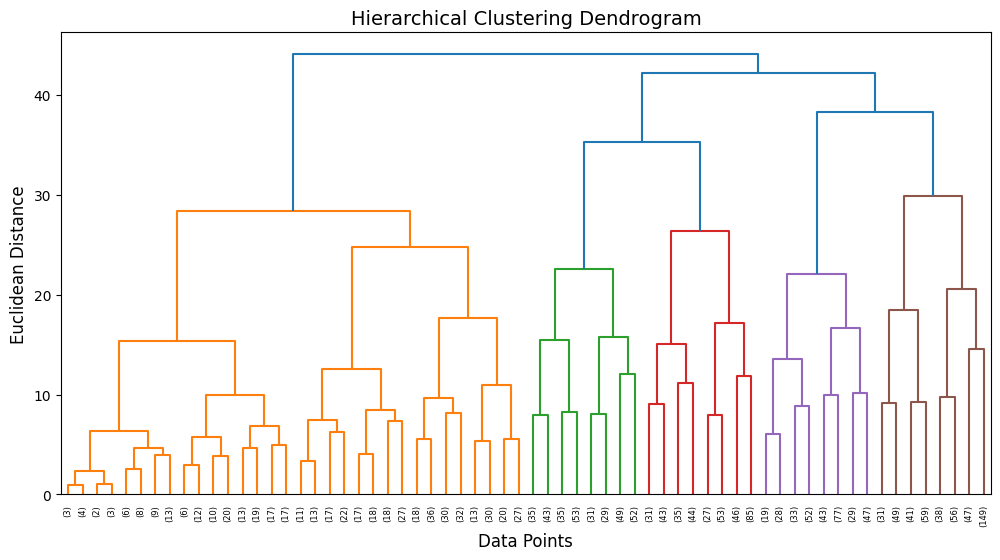

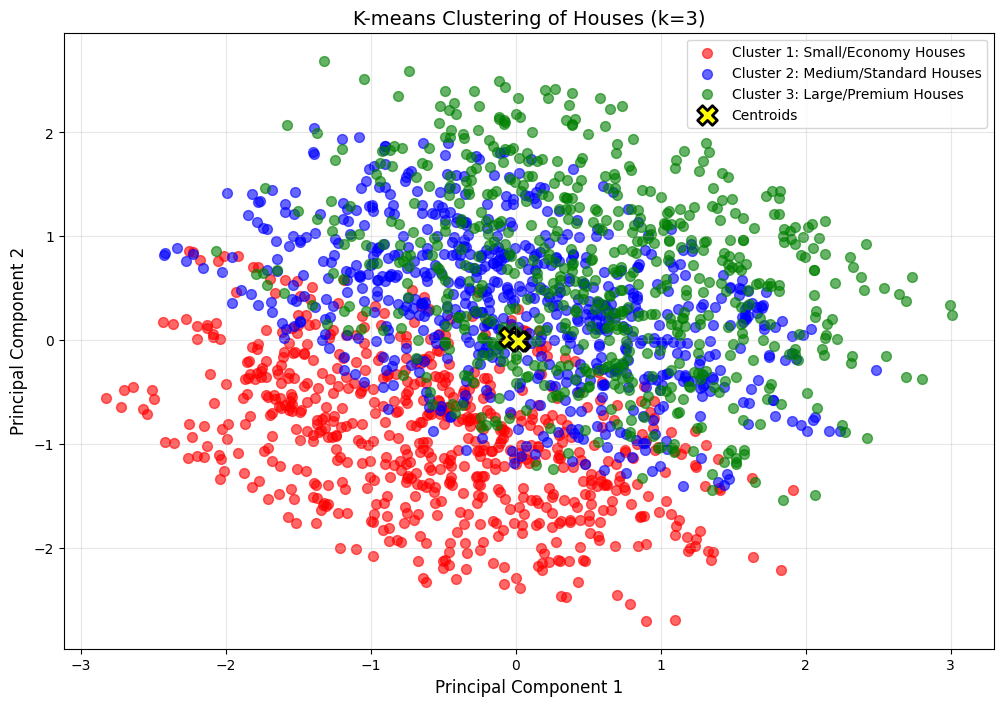


CLUSTER ANALYSIS - DETAILED STATISTICS

📊 Cluster 1: Small/Economy Houses
  Number of houses: 659
  Average Area: 2726 sq ft
  Average Bedrooms: 3.0
  Average Bathrooms: 1.5
  Average Floors: 1.5
  Average Year Built: 1962

📊 Cluster 2: Medium/Standard Houses
  Number of houses: 693
  Average Area: 2825 sq ft
  Average Bedrooms: 3.0
  Average Bathrooms: 3.5
  Average Floors: 1.5
  Average Year Built: 1962

📊 Cluster 3: Large/Premium Houses
  Number of houses: 648
  Average Area: 2805 sq ft
  Average Bedrooms: 3.0
  Average Bathrooms: 2.6
  Average Floors: 3.0
  Average Year Built: 1960


In [20]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Select features for clustering
features_for_clustering = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
cluster_data = df[features_for_clustering].copy()

# Scale the data
scaler_cluster = StandardScaler()
cluster_data_scaled = scaler_cluster.fit_transform(cluster_data)

# ============================================
# METHOD 1: ELBOW METHOD FOR OPTIMAL K
# ============================================
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(cluster_data_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', linewidth=2, markersize=8, color='blue')
plt.title('Elbow Method for Optimal Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.show()

# Based on elbow method, choose k=3
optimal_k = 3
print(f"\n✅ Based on Elbow Method, optimal number of clusters: {optimal_k}")

# ============================================
# METHOD 2: HIERARCHICAL CLUSTERING (DENDROGRAM)
# ============================================
plt.figure(figsize=(12, 6))
linked = linkage(cluster_data_scaled, method='ward')
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram', fontsize=14)
plt.xlabel('Data Points', fontsize=12)
plt.ylabel('Euclidean Distance', fontsize=12)
plt.show()

# ============================================
# APPLY K-MEANS WITH K=3
# ============================================
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(cluster_data_scaled)
cluster_data['Cluster'] = clusters
df['Cluster'] = clusters

# ============================================
# VISUALIZE CLUSTERS USING PCA
# ============================================
pca = PCA(n_components=2)
principal_components = pca.fit_transform(cluster_data_scaled)

plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green']
cluster_names = [
    'Cluster 1: Small/Economy Houses',
    'Cluster 2: Medium/Standard Houses',
    'Cluster 3: Large/Premium Houses'
]

for i in range(optimal_k):
    plt.scatter(principal_components[clusters==i, 0],
                principal_components[clusters==i, 1],
                s=50, c=colors[i], label=cluster_names[i], alpha=0.6)

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='yellow', marker='X', edgecolors='black', linewidths=2, label='Centroids')

plt.title('K-means Clustering of Houses (k=3)', fontsize=14)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# CLUSTER STATISTICS
# ============================================
print("\n" + "=" * 70)
print("CLUSTER ANALYSIS - DETAILED STATISTICS")
print("=" * 70)

for i in range(optimal_k):
    cluster_subset = cluster_data[cluster_data['Cluster'] == i]
    print(f"\n{'='*50}")
    print(f"📊 {cluster_names[i]}")
    print(f"{'='*50}")
    print(f"  Number of houses: {len(cluster_subset)}")
    print(f"  Average Area: {cluster_subset['Area'].mean():.0f} sq ft")
    print(f"  Average Bedrooms: {cluster_subset['Bedrooms'].mean():.1f}")
    print(f"  Average Bathrooms: {cluster_subset['Bathrooms'].mean():.1f}")
    print(f"  Average Floors: {cluster_subset['Floors'].mean():.1f}")
    print(f"  Average Year Built: {cluster_subset['YearBuilt'].mean():.0f}")